# Modelagem Preditiva de Churn

**Objetivo:** treinar e comparar três classificadores para prever churn no dataset Telco.

- **Regressão Logística** (linear, interpretável, baseline canônico)
- **Random Forest** (não-linear, robusta a multicolinearidade)
- **MLP em PyTorch** (rede neural, expressividade alta)

Os três compartilham o mesmo pipeline de pré-processamento (`features/preprocessing.py`) e o mesmo split estratificado (`data/loader.py`), garantindo comparação justa.

**Métricas:** ROC-AUC (primária), F1-score (secundária), matriz de confusão.

## 1. Setup

In [1]:
from __future__ import annotations
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.metrics import (
    auc, average_precision_score, classification_report, confusion_matrix,
    f1_score, precision_recall_curve, roc_auc_score, roc_curve,
)

from churn_predictor.config import MODELS_DIR, RANDOM_SEED
from churn_predictor.data.loader import get_train_test_split
from churn_predictor.features.preprocessing import build_preprocessor
from churn_predictor.models.baseline import (
    build_logreg, build_random_forest, evaluate,
)

np.random.seed(RANDOM_SEED)
sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

## 2. Carga dos dados e split estratificado

Usamos o pipeline da Etapa 1: carrega `data/interim/telco_clean.parquet`, separa `X` e `y`, aplica split 80/20 estratificado por `Churn`.

In [2]:
X_train, X_test, y_train, y_test = get_train_test_split()

print(f"Train shape: {X_train.shape}")
print(f"Test shape:  {X_test.shape}")
print(f"\nChurn rate train: {y_train.mean():.4f}")
print(f"Churn rate test:  {y_test.mean():.4f}")

2026-05-02 23:02:44 [info     ] clean_data_loaded              shape=(7043, 21)
2026-05-02 23:02:44 [info     ] train_test_split               test_churn_rate=0.2654364797728886 test_shape=(1409, 19) train_churn_rate=0.2653532126375577 train_shape=(5634, 19)
Train shape: (5634, 19)
Test shape:  (1409, 19)

Churn rate train: 0.2654
Churn rate test:  0.2654


## 3. Baselines clássicos

### 3.1 Regressão Logística

Modelo linear com `class_weight='balanced'` para tratar o desbalanceamento (26,5% positivos). O preprocessor faz scaling nas numéricas e one-hot nas categóricas dentro do mesmo Pipeline — garante que `fit` só veja o train.

In [3]:
logreg = build_logreg()
logreg.fit(X_train, y_train)
logreg_metrics = evaluate(logreg, X_test, y_test, "logreg")

# PR-AUC (Average Precision): métrica primária em datasets desbalanceados
logreg_proba = logreg.predict_proba(X_test)[:, 1]
logreg_metrics["pr_auc"] = float(average_precision_score(y_test, logreg_proba))

print(f"ROC-AUC: {logreg_metrics['roc_auc']:.4f}")
print(f"PR-AUC:  {logreg_metrics['pr_auc']:.4f}")
print(f"F1:      {logreg_metrics['f1']:.4f}")
print()
print(classification_report(y_test, logreg.predict(X_test), target_names=["No", "Yes"]))

2026-05-02 23:02:44 [info     ] model_evaluated                f1=0.6164 model=logreg roc_auc=0.8419
ROC-AUC: 0.8419
PR-AUC:  0.6341
F1:      0.6164

              precision    recall  f1-score   support

          No       0.90      0.72      0.80      1035
         Yes       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



### 3.2 Random Forest

Ensemble de 200 árvores. Não exige scaling (mas o pipeline aplica do mesmo jeito — sem prejuízo). Captura interações não-lineares entre features.

In [4]:
rf = build_random_forest()
rf.fit(X_train, y_train)
rf_metrics = evaluate(rf, X_test, y_test, "random_forest")

rf_proba = rf.predict_proba(X_test)[:, 1]
rf_metrics["pr_auc"] = float(average_precision_score(y_test, rf_proba))

print(f"ROC-AUC: {rf_metrics['roc_auc']:.4f}")
print(f"PR-AUC:  {rf_metrics['pr_auc']:.4f}")
print(f"F1:      {rf_metrics['f1']:.4f}")
print()
print(classification_report(y_test, rf.predict(X_test), target_names=["No", "Yes"]))

2026-05-02 23:02:44 [info     ] model_evaluated                f1=0.6066 model=random_forest roc_auc=0.838
ROC-AUC: 0.8380
PR-AUC:  0.6406
F1:      0.6066

              precision    recall  f1-score   support

          No       0.86      0.83      0.85      1035
         Yes       0.58      0.64      0.61       374

    accuracy                           0.78      1409
   macro avg       0.72      0.73      0.73      1409
weighted avg       0.79      0.78      0.78      1409



### 3.3 Comparação visual: matrizes de confusão e ROC curves

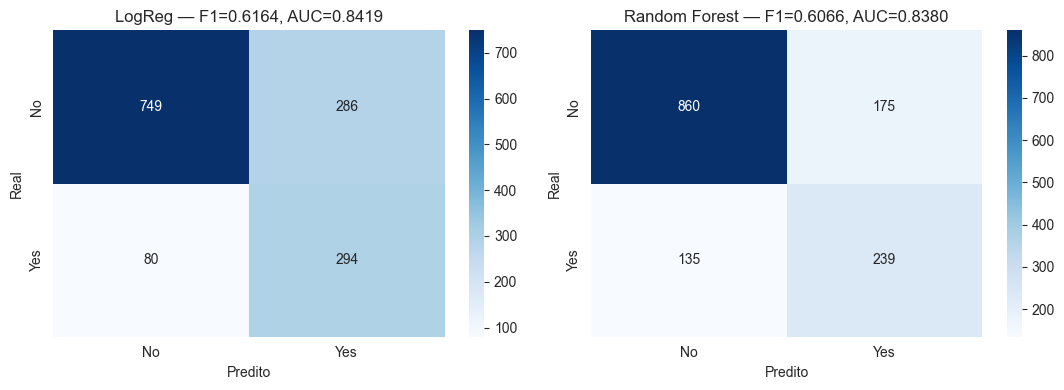

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (name, metrics) in zip(axes, [("LogReg", logreg_metrics), ("Random Forest", rf_metrics)]):
    cm = np.array(metrics["confusion_matrix"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["No", "Yes"], yticklabels=["No", "Yes"], ax=ax)
    ax.set_title(f"{name} — F1={metrics['f1']:.4f}, AUC={metrics['roc_auc']:.4f}")
    ax.set_xlabel("Predito")
    ax.set_ylabel("Real")
plt.tight_layout()
plt.show()

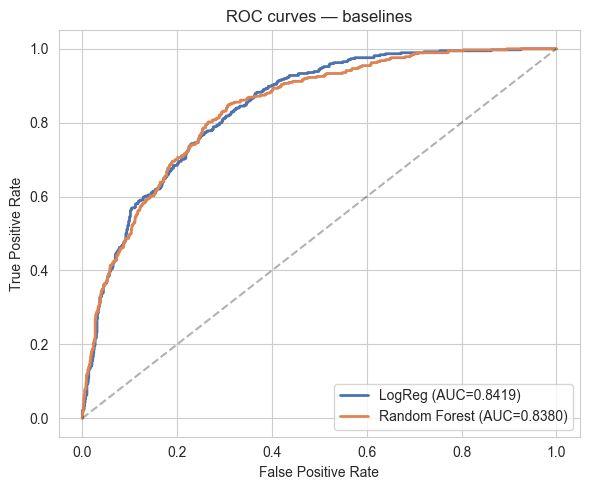

In [6]:
logreg_proba = logreg.predict_proba(X_test)[:, 1]
rf_proba = rf.predict_proba(X_test)[:, 1]

fig, ax = plt.subplots(figsize=(6, 5))
for name, proba, color in [
    ("LogReg", logreg_proba, "#4c72b0"),
    ("Random Forest", rf_proba, "#dd8452"),
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc(fpr, tpr):.4f})", linewidth=2, color=color)

ax.plot([0, 1], [0, 1], "k--", alpha=0.3)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC curves — baselines")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

**Observação parcial:** os dois modelos saem virtualmente empatados em ROC-AUC (~0,84). LogReg tem `recall` mais alto (mais agressiva em prever churn); RF tem `precision` mais alta (mais conservadora). A escolha entre as duas depende do custo de FN vs. FP do negócio.

Vamos ver se o MLP consegue superar esse patamar.

## 4. MLP (PyTorch)

Rede neural totalmente conectada com duas camadas ocultas (64 e 32 neurônios), ReLU, dropout 0.3 e saída em logit. Treinada com `BCEWithLogitsLoss` ponderada por `pos_weight ≈ 2.77` (proporção 73,5/26,5) para compensar o desbalanceamento.

**Estratégia de treino:** Adam (lr=1e-3), batch_size=128, até 100 epochs com **early stopping** (paciência 10 em ROC-AUC do conjunto de validação interno — 15% retirado do train).

In [7]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split

from churn_predictor.models.dataset import ChurnDataset
from churn_predictor.models.mlp import ChurnMLP

# Aplica o preprocessor uma única vez (já fitado nos baselines não serve — refazemos pra ficar isolado)
prep = build_preprocessor()
X_train_t = prep.fit_transform(X_train)
X_test_t = prep.transform(X_test)

# Holdout interno do train: 15% pra validação durante o treino
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_t, y_train.values,
    test_size=0.15,
    stratify=y_train,
    random_state=RANDOM_SEED,
)

print(f"Train interno: {X_tr.shape}")
print(f"Validação:     {X_val.shape}")
print(f"Test:          {X_test_t.shape}")

Train interno: (4788, 23)
Validação:     (846, 23)
Test:          (1409, 23)


In [8]:
BATCH_SIZE = 128

train_loader = DataLoader(
    ChurnDataset(X_tr, y_tr), batch_size=BATCH_SIZE, shuffle=True,
)
val_loader = DataLoader(
    ChurnDataset(X_val, y_val), batch_size=256, shuffle=False,
)
test_loader = DataLoader(
    ChurnDataset(X_test_t, y_test.values), batch_size=256, shuffle=False,
)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")
print(f"Test batches:  {len(test_loader)}")

Train batches: 38
Val batches:   4
Test batches:  6


C:\fiap\fiap_tc01_churn\src\churn_predictor\models\dataset.py:14: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  self.y = torch.as_tensor(np.asarray(y), dtype=torch.float32)


In [9]:
torch.manual_seed(RANDOM_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

model = ChurnMLP(input_dim=X_train_t.shape[1]).to(device)
print(model)

# pos_weight = (n_negativos / n_positivos) no train interno
pos_weight = torch.tensor(
    [(y_tr == 0).sum() / (y_tr == 1).sum()],
    dtype=torch.float32,
    device=device,
)
print(f"\npos_weight: {pos_weight.item():.4f}")

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

Device: cpu
ChurnMLP(
  (net): Sequential(
    (0): Linear(in_features=23, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)

pos_weight: 2.7671


In [10]:
# loop de treino
EPOCHS = 100
PATIENCE = 10

best_val_auc = 0.0
best_state = None
patience_counter = 0
history = {"train_loss": [], "val_loss": [], "val_auc": []}

for epoch in range(1, EPOCHS + 1):
    # --- Train
    model.train()
    train_losses = []
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb).squeeze(-1)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

    # --- Val
    model.eval()
    val_losses, val_probas, val_targets = [], [], []
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb).squeeze(-1)
            val_losses.append(criterion(logits, yb).item())
            val_probas.extend(torch.sigmoid(logits).cpu().numpy())
            val_targets.extend(yb.cpu().numpy())

    val_auc = roc_auc_score(val_targets, val_probas)
    history["train_loss"].append(np.mean(train_losses))
    history["val_loss"].append(np.mean(val_losses))
    history["val_auc"].append(val_auc)

    # Early stopping
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1

    if epoch == 1 or epoch % 5 == 0:
        print(f"Epoch {epoch:3d} | train_loss={np.mean(train_losses):.4f} | val_loss={np.mean(val_losses):.4f} | val_auc={val_auc:.4f}")

    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping na epoch {epoch}. Melhor val AUC: {best_val_auc:.4f}")
        break

# Restaura melhores pesos
model.load_state_dict(best_state)
print(f"\nPesos do melhor checkpoint restaurados (val AUC = {best_val_auc:.4f})")

Epoch   1 | train_loss=1.0186 | val_loss=1.0177 | val_auc=0.6668
Epoch   5 | train_loss=0.9744 | val_loss=0.9648 | val_auc=0.8142
Epoch  10 | train_loss=0.8471 | val_loss=0.8309 | val_auc=0.8300
Epoch  15 | train_loss=0.7667 | val_loss=0.7515 | val_auc=0.8360
Epoch  20 | train_loss=0.7509 | val_loss=0.7343 | val_auc=0.8389
Epoch  25 | train_loss=0.7461 | val_loss=0.7288 | val_auc=0.8416
Epoch  30 | train_loss=0.7373 | val_loss=0.7266 | val_auc=0.8426
Epoch  35 | train_loss=0.7380 | val_loss=0.7260 | val_auc=0.8434
Epoch  40 | train_loss=0.7252 | val_loss=0.7251 | val_auc=0.8436
Epoch  45 | train_loss=0.7325 | val_loss=0.7245 | val_auc=0.8442
Epoch  50 | train_loss=0.7316 | val_loss=0.7241 | val_auc=0.8445
Epoch  55 | train_loss=0.7223 | val_loss=0.7235 | val_auc=0.8447
Epoch  60 | train_loss=0.7173 | val_loss=0.7229 | val_auc=0.8448
Epoch  65 | train_loss=0.7133 | val_loss=0.7236 | val_auc=0.8446
Epoch  70 | train_loss=0.7155 | val_loss=0.7229 | val_auc=0.8445
Epoch  75 | train_loss=0.

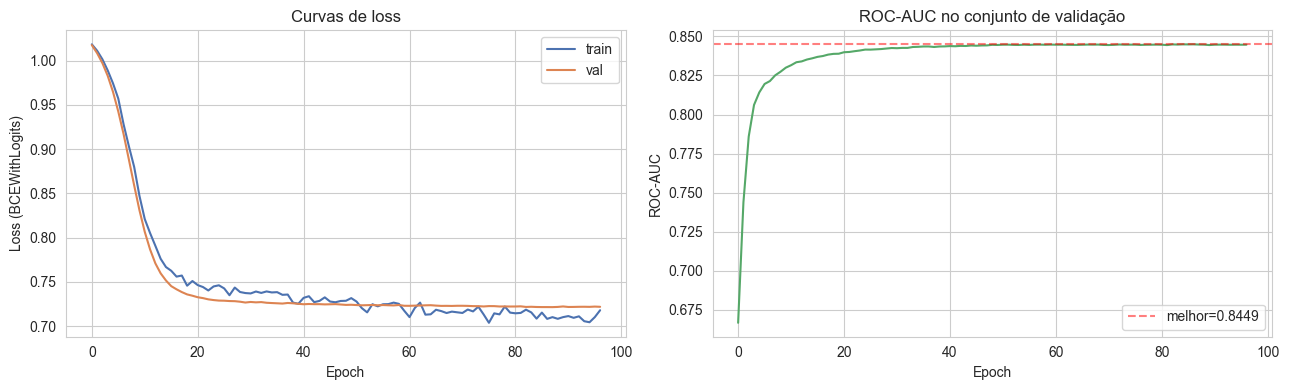

In [11]:
# curvas de treino

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history["train_loss"], label="train", color="#4c72b0")
axes[0].plot(history["val_loss"], label="val", color="#dd8452")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss (BCEWithLogits)")
axes[0].set_title("Curvas de loss")
axes[0].legend()

axes[1].plot(history["val_auc"], color="#55a868")
axes[1].axhline(best_val_auc, color="red", linestyle="--", alpha=0.5, label=f"melhor={best_val_auc:.4f}")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("ROC-AUC")
axes[1].set_title("ROC-AUC no conjunto de validação")
axes[1].legend()

plt.tight_layout()
plt.show()

In [12]:
# avaliação no test
model.eval()
test_probas, test_preds, test_targets = [], [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        probas = torch.sigmoid(model(xb).squeeze(-1)).cpu().numpy()
        test_probas.extend(probas)
        test_preds.extend((probas >= 0.5).astype(int))
        test_targets.extend(yb.numpy())

test_probas = np.array(test_probas)
test_preds = np.array(test_preds)
test_targets = np.array(test_targets)

mlp_metrics = {
    "model": "mlp",
    "roc_auc": float(roc_auc_score(test_targets, test_probas)),
    "pr_auc": float(average_precision_score(test_targets, test_probas)),
    "f1": float(f1_score(test_targets, test_preds)),
    "confusion_matrix": confusion_matrix(test_targets, test_preds).tolist(),
}

print(f"ROC-AUC: {mlp_metrics['roc_auc']:.4f}")
print(f"PR-AUC:  {mlp_metrics['pr_auc']:.4f}")
print(f"F1:      {mlp_metrics['f1']:.4f}")
print()
print(classification_report(test_targets, test_preds, target_names=["No", "Yes"]))

ROC-AUC: 0.8432
PR-AUC:  0.6358
F1:      0.6255

              precision    recall  f1-score   support

          No       0.91      0.73      0.81      1035
         Yes       0.51      0.80      0.63       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409



## 5. Comparação dos três modelos

In [13]:
# tabela
comparison = pd.DataFrame([logreg_metrics, rf_metrics, mlp_metrics])[
    ["model", "roc_auc", "pr_auc", "f1"]
].round(4)
comparison.set_index("model")

,roc_auc,pr_auc,f1
model,,,
logreg,0.8419,0.6341,0.6164
random_forest,0.8380,0.6406,0.6066
mlp,0.8432,0.6358,0.6255


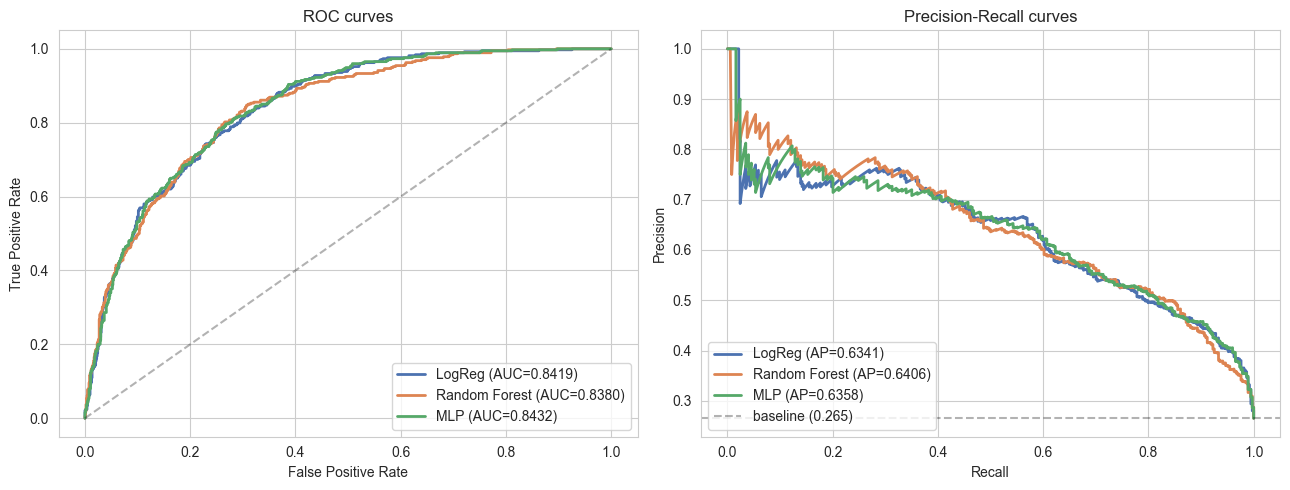

In [14]:
#ROC + PR lado a lado

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC curves
for name, proba, color in [
    ("LogReg", logreg_proba, "#4c72b0"),
    ("Random Forest", rf_proba, "#dd8452"),
    ("MLP", test_probas, "#55a868"),
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={auc(fpr, tpr):.4f})",
                 linewidth=2, color=color)
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.3)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC curves")
axes[0].legend(loc="lower right")

# Precision-Recall curves
baseline_pr = y_test.mean()
for name, proba, color in [
    ("LogReg", logreg_proba, "#4c72b0"),
    ("Random Forest", rf_proba, "#dd8452"),
    ("MLP", test_probas, "#55a868"),
]:
    precision, recall, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    axes[1].plot(recall, precision, label=f"{name} (AP={ap:.4f})",
                 linewidth=2, color=color)
axes[1].axhline(baseline_pr, color="k", linestyle="--", alpha=0.3,
                label=f"baseline ({baseline_pr:.3f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall curves")
axes[1].legend(loc="lower left")

plt.tight_layout()
plt.show()

## 6. Persistência do modelo vencedor

O melhor modelo (maior ROC-AUC) é salvo em `models/final.joblib` para a API consumir.

Para LogReg/RF, o `Pipeline` sklearn já contém o preprocessor — basta `joblib.dump(pipeline)`. Para o MLP, salvamos o `state_dict` do PyTorch + o preprocessor sklearn separadamente, já que o `nn.Module` não inclui o pré-processamento.

In [15]:
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Critério de seleção: maior PR-AUC (mais robusta a desbalanceamento)
winner = comparison.loc[comparison["pr_auc"].idxmax(), "model"]
print(f"Modelo vencedor (por PR-AUC): {winner}")
print(f"PR-AUC: {comparison.loc[comparison['model'] == winner, 'pr_auc'].iloc[0]:.4f}")

if winner == "logreg":
    joblib.dump(logreg, MODELS_DIR / "final.joblib")
    print(f"Salvo: {MODELS_DIR / 'final.joblib'}")
elif winner == "random_forest":
    joblib.dump(rf, MODELS_DIR / "final.joblib")
    print(f"Salvo: {MODELS_DIR / 'final.joblib'}")
else:  # mlp
    torch.save(model.state_dict(), MODELS_DIR / "final_mlp.pt")
    joblib.dump(prep, MODELS_DIR / "final_preprocessor.joblib")
    print(f"Salvos: final_mlp.pt + final_preprocessor.joblib")

Modelo vencedor (por PR-AUC): random_forest
PR-AUC: 0.6406
Salvo: C:\fiap\fiap_tc01_churn\models\final.joblib
